In [136]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import cosmology
from astropy import units as u

### Problem 2

In [137]:
def volume(radius):
    return (4/3) * np.pi * radius**3

def density_object(mass, radius):
    volume = (4/3) * np.pi * radius**3
    print("The volume: {:2E}".format(volume))
    density_obj = mass / volume
    print("The density: {:2E}".format(density_obj))
    return density_obj

def omega_object(den_obj, den_crit = 1.36e11):
    omega_obj = den_obj / den_crit
    return omega_obj

In [138]:
glob_mass = 1e6
glob_rad = 1.5e-5

print("Omega Object Glob Cluster: {:2E}".format(omega_object(density_object(glob_mass, glob_rad))))

The volume: 1.413717E-14
The density: 7.073553E+19
Omega Object Glob Cluster: 5.201142E+08


In [139]:
mw_mass = 1.5e12
mw_rad = 0.03

print("Omega Object MW: {:2E}".format(omega_object(density_object(mw_mass, mw_rad))))

The volume: 1.130973E-04
The density: 1.326291E+16
Omega Object MW: 9.752141E+04


In [140]:
lg_mass = 2.3e12
lg_rad = 1.5

print("Omega Object Local Group: {}".format(omega_object(density_object(lg_mass, lg_rad))))

The volume: 1.413717E+01
The density: 1.626917E+11
Omega Object Local Group: 1.196262644154769


In [141]:
coma_mass = 1e15
coma_rad = 1.78

print("Omega Object Coma Cluster: {}".format(omega_object(density_object(coma_mass, coma_rad))))

The volume: 2.362374E+01
The density: 4.233030E+13
Omega Object Coma Cluster: 311.2522326777571


### Problem 3

In [142]:
plt.rcParams.update({'font.size': 16})

In [143]:
universe=cosmology.LambdaCDM(H0=72, Om0=0.3, Ode0=0.7)

In [144]:
# set up some redshifts of interest
zs = [0,0.00396, 0.01, 0.1, 0.5, 1, 5]

# calculate interesting quantities at those redshifts
for z in zs:

    print("The rest frame is: {}".format(5500/(1+z)))
    
    print ('Redshift = {}'.format(z))
    
    ######################
    # LUMINOSITY DISTANCE (DL) is what you use when calculating apparent magnitudes,
    # i.e., m - M = 5*np.log10(DL) - 5 (and remember DL should have units of parsecs!)
    DL=universe.luminosity_distance(z)
    print('  Luminosity distance is {:.2f}'.format(DL))

    # but before you stuff it into the mag-distance equation, make sure DL is in parsecs, 
    # and that you’ve converted it to a regular python number:
    DL_pc = DL.to(u.pc).value
    # and now you can use DL_pc to convert between apparent and absolute magnitudes
    Mv = 5*np.log10(DL_pc) -5- 23.25
    print('  Apparent mag: {}'.format(Mv))


    ######################
    # ANGULAR DIAMETER DISTANCE (DA) is what you use when converting between 
    # angular size (alpha) and physical size (d_phys):
    #d_phys = alpha[arcsec]*DA/206265
    # or
    # d_phys =  DA * np.tan(alpha[radians])
    DA=universe.angular_diameter_distance(z)
    print('  Angular diameter distance is {:.2f}'.format(DA))
    DA_pc = DA.to(u.pc).value
    alpha = 206265*25000/DA_pc
    print('  Angular Half Light: {}'.format(alpha))
    mu = Mv + (2.5*np.log10(np.pi*(alpha**2)))
    print('  Effective Surface Brightness: {}'.format(mu))
    # again, you can convert it to a regular number and unit, for example kpc
    DA_kpc = DA.to(u.kpc).value
    # and now you can use DA_kpc to convert between angular size and physical size
    # in kpc

    ######################
    # AGES AND LOOKBACK TIMES can be worked out this way:
    print('  Universe age is {:.2f}'.format(universe.age(z)))
    print('  Lookback time is {:.2f}'.format(universe.lookback_time(z)))

The rest frame is: 5500.0
Redshift = 0
  Luminosity distance is 0.00 Mpc
  Apparent mag: -inf
  Angular diameter distance is 0.00 Mpc
  Angular Half Light: inf
  Effective Surface Brightness: nan
  Universe age is 13.09 Gyr
  Lookback time is 0.00 Gyr
The rest frame is: 5478.305908601937
Redshift = 0.00396
  Luminosity distance is 16.54 Mpc
  Apparent mag: 7.84256171343965
  Angular diameter distance is 16.41 Mpc
  Angular Half Light: 314.2577718176404
  Effective Surface Brightness: 21.571866529682207
  Universe age is 13.04 Gyr
  Lookback time is 0.05 Gyr
The rest frame is: 5445.544554455446
Redshift = 0.01
  Luminosity distance is 41.96 Mpc
  Apparent mag: 9.864146098827419
  Angular diameter distance is 41.13 Mpc
  Angular Half Light: 125.36580034866054
  Effective Surface Brightness: 21.59791616855545
  Universe age is 12.96 Gyr
  Lookback time is 0.13 Gyr
The rest frame is: 5000.0
Redshift = 0.1
  Luminosity distance is 447.51 Mpc
  Apparent mag: 15.004032292305851
  Angular diam

C:\Users\bhoom\AppData\Local\Temp\ipykernel_75432\2449316728.py:21: RuntimeWarning: divide by zero encountered in log10
  Mv = 5*np.log10(DL_pc) -5- 23.25
C:\Users\bhoom\AppData\Local\Temp\ipykernel_75432\2449316728.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = 206265*25000/DA_pc
C:\Users\bhoom\AppData\Local\Temp\ipykernel_75432\2449316728.py:36: RuntimeWarning: invalid value encountered in scalar add
  mu = Mv + (2.5*np.log10(np.pi*(alpha**2)))


In [145]:
import pandas as pd
# Constants
H0 = 72  # Hubble constant (km/s/Mpc)
c = 3e5  # Speed of light (km/s)
M_abs = -23.25  # Absolute magnitude of M49
R_e = 0.025  # Half-light radius in Mpc
rad_to_arcsec = 206265  # Conversion factor from radians to arcseconds


redshifts = np.array([0.00396, 0.01, 0.1, 0.5, 1, 5])

# Calculations
distances = (c * redshifts) / H0  # Distance in Mpc
apparent_magnitudes = M_abs + 5 * np.log10(distances) + 25
angular_half_light_radii = (R_e / distances) * rad_to_arcsec  # in arcseconds

data = {
    'Redshift (z)': redshifts,
    'Distance (Mpc)': distances,
    'Apparent Magnitude (m)': apparent_magnitudes,
    'Angular Half-Light Radius (arcsec)': angular_half_light_radii
}

df = pd.DataFrame(data)

# Display the table
print(df.to_string(index=False))


 Redshift (z)  Distance (Mpc)  Apparent Magnitude (m)  Angular Half-Light Radius (arcsec)
      0.00396       16.500000                7.837420                          312.522727
      0.01000       41.666667                9.848944                          123.759000
      0.10000      416.666667               14.848944                           12.375900
      0.50000     2083.333333               18.343794                            2.475180
      1.00000     4166.666667               19.848944                            1.237590
      5.00000    20833.333333               23.343794                            0.247518


In [146]:
for z in zs:
    print ('Redshift = {}'.format(z))
    ho = 72
    c = 3e5
    v = c*z
    d = v/ho
    print(" Distance: {:.2f}".format(d))

Redshift = 0
 Distance: 0.00
Redshift = 0.00396
 Distance: 16.50
Redshift = 0.01
 Distance: 41.67
Redshift = 0.1
 Distance: 416.67
Redshift = 0.5
 Distance: 2083.33
Redshift = 1
 Distance: 4166.67
Redshift = 5
 Distance: 20833.33


### Problem 4

In [147]:
from astropy.cosmology import FlatLambdaCDM

# Define cosmology
cosmo = FlatLambdaCDM(70, 0.3, .5)  # H0 = 70 km/s/Mpc, Omega_m = 0.3 (and Omega_Lambda = 0.7 automatically)

# Check the age of the universe
print(f"Age of the universe: {cosmo.age(0):.2f}")


Age of the universe: 13.47 Gyr


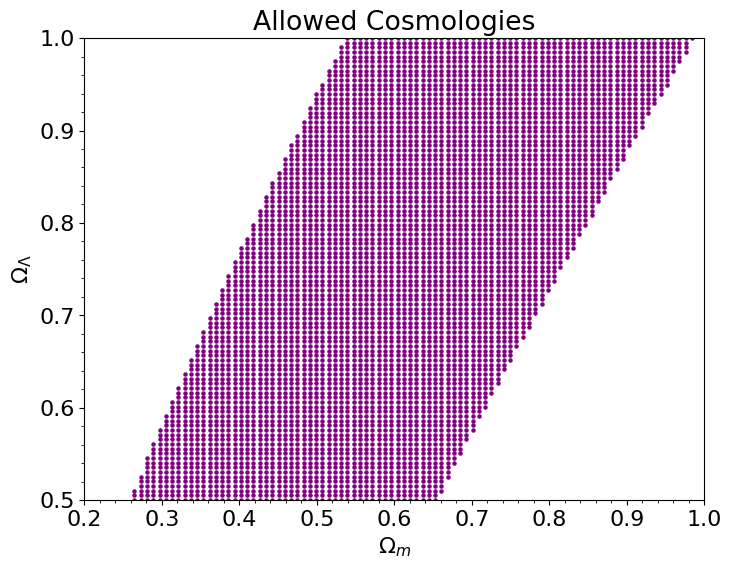

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM

H0 = 70  # km/s/Mpc
age_min = 11  # Gyr
age_max = 13  # Gyr

# Make a grid
Om0_vals = np.linspace(0.2, 1, 100)
Ode0_vals = np.linspace(0.5, 1, 100)

allowed = []

for Om0 in Om0_vals:
    for Ode0 in Ode0_vals:
        try:
            cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=Ode0)
            age = cosmo.age(0).value  # Gyr
            if age_min <= age <= age_max:
                allowed.append((Om0, Ode0))
        except:
            pass  # Ignore cosmologies that crash (e.g., bad parameters)

allowed = np.array(allowed)

plt.figure(figsize=(8,6))
plt.scatter(allowed[:,0], allowed[:,1], s=5, color='purple')
plt.xlabel(r'$\Omega_m$')
plt.ylabel(r'$\Omega_\Lambda$')
plt.xlim(.2,1)
plt.ylim(.5,1)
plt.title('Allowed Cosmologies')
plt.minorticks_on()
plt.show()


In [1]:
i = 0
while i <= 35:
    z = 1.55
    print(i/10)
    universe = cosmology.LambdaCDM(70, i/10, 0 )
    print(f"Universe age = {universe.age(0):.2f}")
    i += 1
    print ('Redshift = {}'.format(z))
    """
    ######################
    # LUMINOSITY DISTANCE (DL) is what you use when calculating apparent magnitudes,
    # i.e., m - M = 5*np.log10(DL) - 5 (and remember DL should have units of parsecs!)
    DL=universe.luminosity_distance(z)
    print('  Luminosity distance is {:.2f}'.format(DL))

    # but before you stuff it into the mag-distance equation, make sure DL is in parsecs, 
    # and that you’ve converted it to a regular python number:
    DL_pc = DL.to(u.pc).value
    # and now you can use DL_pc to convert between apparent and absolute magnitudes

    ######################
    # ANGULAR DIAMETER DISTANCE (DA) is what you use when converting between 
    # angular size (alpha) and physical size (d_phys):
    # d_phys = alpha[arcsec]*DA/206265
    # or
    # d_phys =  DA * np.tan(alpha[radians])
    DA=universe.angular_diameter_distance(z)
    print('  Angular diameter distance is {:.2f}'.format(DA))

    # again, you can convert it to a regular number and unit, for example kpc
    DA_kpc = DA.to(u.kpc).value
    # and now you can use DA_kpc to convert between angular size and physical size
    # in kpc

    ######################
    # AGES AND LOOKBACK TIMES can be worked out this way:
    print('  Universe age is {:.2f}'.format(universe.age(z)))
    print('  Lookback time is {:.2f}'.format(universe.lookback_time(z)))

    print(universe.age(z) + universe.lookback_time(z))
    """


0.0


NameError: name 'cosmology' is not defined

In [150]:
z = [1.55]

# calculate interesting quantities at those redshifts
for z in zs:
    
    print ('Redshift = {}'.format(z))
    
    ######################
    # LUMINOSITY DISTANCE (DL) is what you use when calculating apparent magnitudes,
    # i.e., m - M = 5*np.log10(DL) - 5 (and remember DL should have units of parsecs!)
    DL=universe.luminosity_distance(z)
    print('  Luminosity distance is {:.2f}'.format(DL))

    # but before you stuff it into the mag-distance equation, make sure DL is in parsecs, 
    # and that you’ve converted it to a regular python number:
    DL_pc = DL.to(u.pc).value
    # and now you can use DL_pc to convert between apparent and absolute magnitudes

    ######################
    # ANGULAR DIAMETER DISTANCE (DA) is what you use when converting between 
    # angular size (alpha) and physical size (d_phys):
    # d_phys = alpha[arcsec]*DA/206265
    # or
    # d_phys =  DA * np.tan(alpha[radians])
    DA=universe.angular_diameter_distance(z)
    print('  Angular diameter distance is {:.2f}'.format(DA))

    # again, you can convert it to a regular number and unit, for example kpc
    DA_kpc = DA.to(u.kpc).value
    # and now you can use DA_kpc to convert between angular size and physical size
    # in kpc

    ######################
    # AGES AND LOOKBACK TIMES can be worked out this way:
    print('  Universe age is {:.2f}'.format(universe.age(z)))
    print('  Lookback time is {:.2f}'.format(universe.lookback_time(z)))

Redshift = 0
  Luminosity distance is 0.00 Mpc
  Angular diameter distance is 0.00 Mpc
  Universe age is 6.87 Gyr
  Lookback time is 0.00 Gyr
Redshift = 0.00396
  Luminosity distance is 16.93 Mpc
  Angular diameter distance is 16.80 Mpc
  Universe age is 6.81 Gyr
  Lookback time is 0.05 Gyr
Redshift = 0.01
  Luminosity distance is 42.67 Mpc
  Angular diameter distance is 41.83 Mpc
  Universe age is 6.73 Gyr
  Lookback time is 0.14 Gyr
Redshift = 0.1
  Luminosity distance is 414.53 Mpc
  Angular diameter distance is 342.59 Mpc
  Universe age is 5.69 Gyr
  Lookback time is 1.18 Gyr
Redshift = 0.5
  Luminosity distance is 1914.10 Mpc
  Angular diameter distance is 850.71 Mpc
  Universe age is 3.24 Gyr
  Lookback time is 3.62 Gyr
Redshift = 1
  Luminosity distance is 3623.37 Mpc
  Angular diameter distance is 905.84 Mpc
  Universe age is 2.00 Gyr
  Lookback time is 4.87 Gyr
Redshift = 5
  Luminosity distance is 15698.81 Mpc
  Angular diameter distance is 436.08 Mpc
  Universe age is 0.35 G